In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import gzip

#Fragment Length Frequency


### 1. Reading the .bed.gz file
The BED file was first decompressed using Python’s gzip module and read into a pandas DataFrame. The file uses a standard 6-column BED format, which includes chromosome name, start and end positions, and strand information.

In [ ]:
col_names = ['chrom', 'start', 'end', 'score', 'strand1', 'strand2']

with gzip.open('query.bed.gz', 'rt') as f:
    df = pd.read_csv(f, sep='\t', names=col_names, header=None)

df.head()

<ipython-input-3-986257f3206a>:9: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t', names=col_names, header=None)


,chrom,start,end,score,strand1,strand2
0,chr10,32795245,32795315,70,.,+
1,chr11,95864728,95864770,42,.,+
2,chr16,32027808,32027880,72,.,+
3,chr4,76608451,76608515,64,.,+
4,chr18,45847777,45847816,39,.,-


### 2. Calculate Fragment Lengths
In BED files, the second and third columns are the start and end genomic coordinates of each fragment.

Fragment length = end - start

This column will now contain the length in base pairs for each fragment.

In [ ]:
df['fragment_length'] = df['end'] - df['start']

### 3. Count Occurrences of Each Fragment Length
value_counts() counts how many times each unique fragment length appears.

sort_index() sorts the counts by fragment length (in ascending order), so your X-axis is properly arranged.

This gives a frequency distribution of fragment lengths.

In [ ]:
length_counts = df['fragment_length'].value_counts().sort_index()

### 4. Normalize the Counts
This converts raw counts into normalized frequencies.

It ensures the area under the curve (sum of all values) is 1.0, which is useful when comparing distributions.

This also means the Y-axis is in "Normalized Frequency [A.U.]", where A.U. = arbitrary units.

In [ ]:
normalized_counts = length_counts / length_counts.sum()

### 5. Plot the Distribution
A simple line plot to visualize the distribution.

normalized_counts.index → fragment lengths (X-axis)

normalized_counts.values → normalized frequencies (Y-axis)


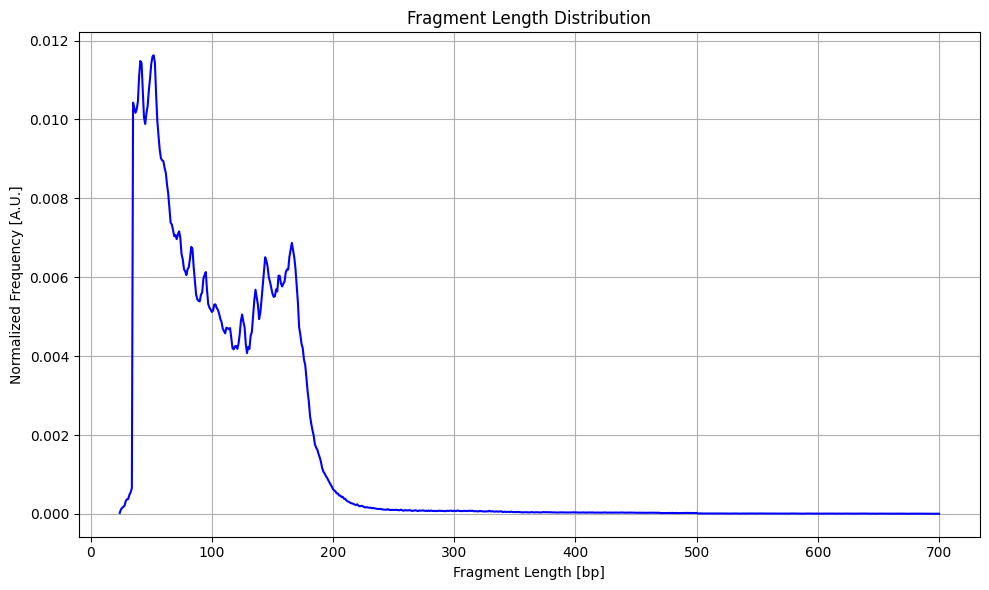

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(normalized_counts.index, normalized_counts.values, color='blue')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary
We first calculated the length of each DNA fragment by subtracting the start coordinate from the end coordinate in the BED file. Then, we counted the number of fragments of each unique length and normalized the counts to obtain a relative frequency distribution. Finally, we plotted the normalized frequencies against fragment lengths to visualize the distribution of DNA fragment sizes across the dataset.

# Rescaling Query Data to Match Reference Distribution


### 1. Load the Reference Distribution
The reference distribution is provided in a file named 'reference.hist'.
We'll read it into a pandas DataFrame. Assumed format:
two columns, first is the fragment length and the second is the frequency.

In [6]:
reference_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['fragment_length', 'frequency'])
reference_df.head()

,fragment_length,frequency
0,24,0.000013
1,25,0.000063
2,26,0.000092
3,27,0.000117
4,28,0.000136


### 2. Calculate Target Fragment Counts
We need to determine how many fragments of each length we need in our query data
to match the reference distribution. This involves scaling the reference frequencies
by the total number of fragments in the query data.

In [8]:
total_query_fragments = len(df)
target_counts = (reference_df['frequency'] * total_query_fragments).astype(int)
target_counts = pd.Series(target_counts.values, index=reference_df['fragment_length'])

### 3. Subsample the Query Data
Now we'll subsample the query data to achieve the target fragment counts.
For each fragment length, we'll randomly select the required number of fragments
from the query data.

In [10]:
grouped = df.groupby('fragment_length')

# Prepare a list to collect subsampled fragments
subsampled_fragments = []

# Loop over target fragment lengths
for length, count in target_counts.items():
    if length in grouped.groups:
        fragments = grouped.get_group(length)
        if len(fragments) >= count:
            sampled = fragments.sample(n=count, random_state=42)
        else:
            sampled = fragments
        subsampled_fragments.append(sampled)

# Concatenate once at the end
subsampled_df = pd.concat(subsampled_fragments, ignore_index=True)

### 4. Verify Rescaling by Plotting
Let's plot the normalized frequency distribution of the subsampled query data
and compare it to the reference distribution.

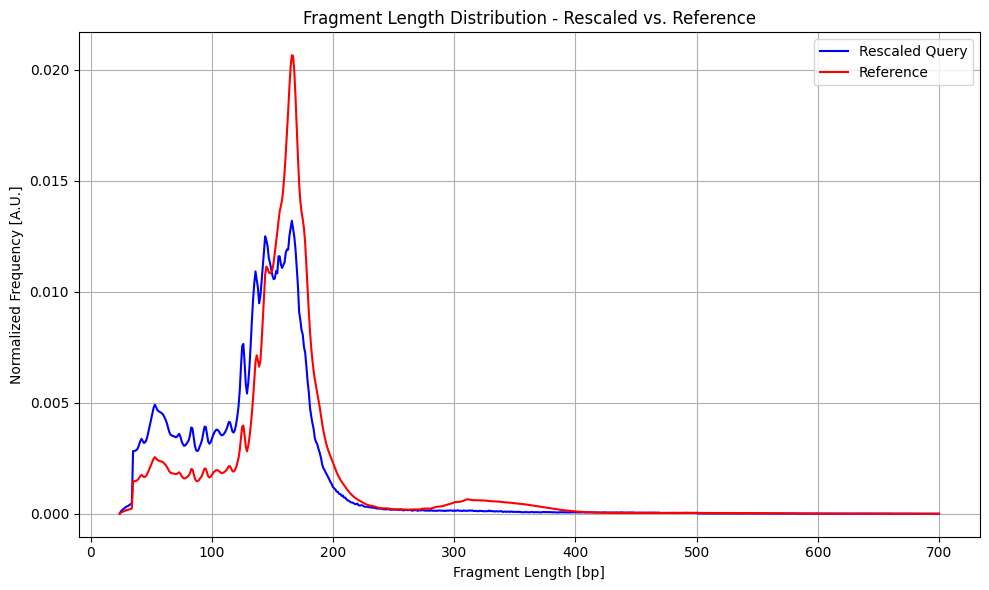

In [11]:
subsampled_length_counts = subsampled_df['fragment_length'].value_counts().sort_index()
subsampled_normalized_counts = subsampled_length_counts / subsampled_length_counts.sum()

plt.figure(figsize=(10, 6))
plt.plot(subsampled_normalized_counts.index, subsampled_normalized_counts.values, color='blue', label='Rescaled Query')
plt.plot(reference_df['fragment_length'], reference_df['frequency'], color='red', label='Reference')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution - Rescaled vs. Reference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary
We rescaled the query data by subsampling fragments to match the target fragment counts derived from the reference distribution. The resulting normalized frequency distribution of the rescaled query data should closely resemble the reference distribution.